# EDA · matrices de correlación

**La pregunta:** ¿matriz de las 83 columnas o sólo de las que entran en la matriz maestra?

**La respuesta: las dos, porque responden a cosas distintas.**

| Matriz | Pregunta que responde | Riesgo si se usa sola |
|---|---|---|
| **Completa** (83 col.) | ¿Qué columnas son redundantes entre sí? | Ilegible: 3.403 pares. Y mezcla columnas con y sin fuga |
| **Restringida** (candidatas) | ¿Qué features aportan información distinta al modelo? | Puede ocultar que dos de las elegidas dicen lo mismo |

La completa se usa para **descartar duplicados** (¿hace falta traer eólica de ESIOS *y* de
ENTSO-E si correlacionan 0,9996?). La restringida, para **entender el conjunto de features** que
de verdad va a entrar. Ninguna sustituye a la otra.

## Y una advertencia que va antes de mirar cualquier número

Sobre seis años y medio con tendencias fuertes —la FV instalada se multiplica por seis en el
período— **una correlación alta puede ser sólo tendencia compartida**. Dos series que crecen
juntas correlacionan aunque no tengan nada que ver.

Por eso el bloque C no se salta: mide si cada correlación **se sostiene dentro de cada año** o si
sólo existe al mirar el histórico entero. Una correlación que se desmorona año a año no es una
relación, es una coincidencia temporal — y un modelo entrenado con ella no generaliza.

## Índice

| Bloque | Contenido |
|---|---|
| **A** | Matriz completa, leída como lista de pares redundantes |
| **B** | Mapa por familias: qué grupos se solapan |
| **C** | Estabilidad: ¿la correlación sobrevive dentro de cada año? |
| **D** | Matriz restringida a las candidatas, con etiqueta de fuga |
| **E** | Grupos de redundancia: qué se puede quitar sin perder información |

---
## 0 · Carga

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df = pd.read_parquet(RAIZ / "data" / "bronze" / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
assert df["ts_utc"].duplicated().sum() == 0, "parquet duplicado: regenerar"

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["anio"] = df["ts_local"].dt.year
df["hora"] = df["ts_local"].dt.hour

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

def pick(d, *c):
    for x in c:
        if x is not None and x in d.columns:
            return x
    return None

# Columnas de calendario fuera: correlacionar 'hora' con todo no dice nada útil.
def familia_de(c):
    for p, n in [("cap_inst_", "cap. instalada"), ("cap_disp_", "cap. disponible"),
                 ("esios_gen_", "generación ESIOS"), ("entsoe_", "generación ENTSO-E"),
                 ("load_inter_", "demanda e interc."), ("forecast_", "previsiones"),
                 ("commodities_", "commodities"), ("era5_", "meteorología"),
                 ("calc_", "derivadas"), ("spot_", "precio"), ("tp_", "trayport")]:
        if c.startswith(p):
            return n
    return "otras"

CALENDARIO = {"hour_utc", "hour_local", "hora", "anio", "tensor_index"}
num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in CALENDARIO]
print(f"{len(num)} columnas numéricas · {len(num)*(len(num)-1)//2:,} pares posibles")
print("Por eso un heatmap de todas es ilegible: hay que leerla como lista, no como imagen.")

91 columnas numéricas · 4,095 pares posibles
Por eso un heatmap de todas es ilegible: hay que leerla como lista, no como imagen.


### 0.1 · Inventario: qué columnas entran y cuáles tienen pares indefinidos

Antes de dibujar nada conviene comprobar dos cosas que después no se ven en el mapa: **que
están todas las columnas** que deberían, y **cuántos de sus pares son incalculables**.

Lo segundo importa más de lo que parece. ERA5 aterriza en horas UTC múltiplo de 3 y las tablas
diarias en la hora 00 local, que en UTC son las 22:00 o las 23:00. **No coinciden nunca**, así
que su correlación no es baja: no existe. Si esos NaN se sustituyen por 0 antes de agrupar
—que es lo que hacía la versión anterior de este notebook— el agrupamiento los trata como
«máximamente distintas» cuando en realidad son «desconocidas», y el árbol sale distorsionado.

In [20]:
C_h = df[num].corr()

inventario = pd.DataFrame({
    "familia": [familia_de(c) for c in num],
    "% nulos": df[num].isna().mean().mul(100).round(1).values,
    "pares indefinidos": C_h.isna().sum().values,
}, index=num)

print("Columnas por familia:")
display(inventario["familia"].value_counts().rename("nº columnas").to_frame())

problema = inventario[inventario["pares indefinidos"] > 0].sort_values(
    "pares indefinidos", ascending=False)
print(f"\n{len(problema)} columnas con al menos un par indefinido:")
display(problema)

if len(problema):
    print("Comprobación del mecanismo -- horas UTC en que existe cada tipo de dato:")
    for c in problema.index[:2]:
        print(f"  {c[:38]:38s} {sorted(df.loc[df[c].notna(), 'ts_utc'].dt.hour.unique())}")
    otra = [c for c in num if C_h.loc[problema.index[0], c] != C_h.loc[problema.index[0], c]]
    if otra:
        print(f"  {otra[0][:38]:38s} {sorted(df.loc[df[otra[0]].notna(), 'ts_utc'].dt.hour.unique())}")
    print("\nSin horas en común, la correlación es NaN. Por eso el agrupamiento se hace")
    print("sobre el marco DIARIO, donde todas las series comparten frecuencia.")

Columnas por familia:


,nº columnas
familia,
cap. instalada,18
precio,14
demanda e interc.,13
generación ENTSO-E,11
generación ESIOS,10
meteorología,9
cap. disponible,6
previsiones,4
commodities,3



91 columnas con al menos un par indefinido:


,familia,% nulos,pares indefinidos
cap_inst_ccgt_mw,cap. instalada,95.8,91
cap_inst_pump_mw,cap. instalada,95.8,91
cap_disp_fuel_mw,cap. disponible,95.8,91
cap_inst_fuel_mw,cap. instalada,95.8,91
cap_inst_nuclear_mw,cap. instalada,95.8,91
...,...,...,...
load_inter_ree_netflow_fr,demanda e interc.,0.0,6
forecast_demanda_residual_prev_mw,previsiones,0.0,6
calc_solar_fv_mw,derivadas,0.1,6
calc_hydro_dispatch_mw,derivadas,0.1,6


Comprobación del mecanismo -- horas UTC en que existe cada tipo de dato:
  cap_inst_ccgt_mw                       [np.int32(22), np.int32(23)]
  cap_inst_pump_mw                       [np.int32(22), np.int32(23)]
  entsoe_solar_mw                        [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

Sin horas en común, la correlación es NaN. Por eso el agrupamiento se hace
sobre el marco DIARIO, donde todas las series comparten frecuencia.


---
# A · La matriz completa, vista de cuatro formas

El plan de este bloque es enseñar la matriz de las 83 columnas **tal cual**, comprobar por qué
no se puede leer así, y luego ir reduciéndola hasta que diga algo. Cada paso quita información
a cambio de legibilidad, y conviene ver el intercambio en vez de saltar directamente al
resultado final.

## A.1 · Tal cual, en el orden en que vienen las columnas

Matriz de 91x91 = 8,281 celdas, 4,095 pares únicos


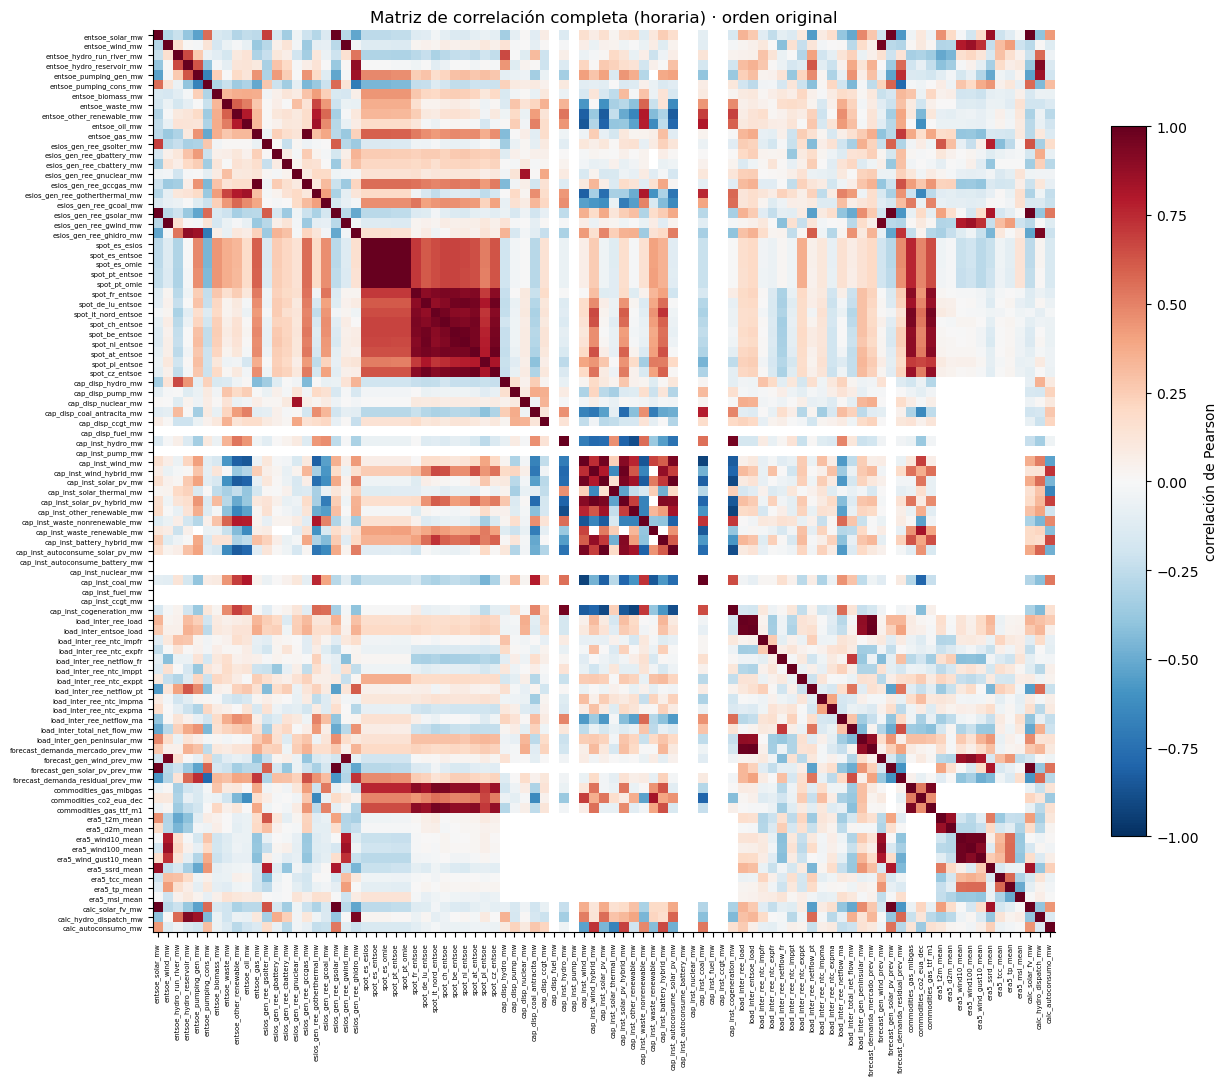

Se intuyen bloques porque las columnas vienen agrupadas por tabla de origen, pero
las etiquetas son ilegibles y no hay forma de identificar un par concreto.


In [21]:
print(f"Matriz de {C_h.shape[0]}x{C_h.shape[1]} = {C_h.shape[0]**2:,} celdas, "
      f"{C_h.shape[0]*(C_h.shape[0]-1)//2:,} pares únicos")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(C_h.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C_h)), C_h.columns, rotation=90, fontsize=5)
ax.set_yticks(range(len(C_h)), C_h.columns, fontsize=5)
ax.set_title("Matriz de correlación completa (horaria) · orden original")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="correlación de Pearson")
plt.tight_layout(); plt.show()

print("Se intuyen bloques porque las columnas vienen agrupadas por tabla de origen, pero")
print("las etiquetas son ilegibles y no hay forma de identificar un par concreto.")

## A.2 · Reordenada por similitud

**El truco que hace legible una matriz grande.** Se agrupan las columnas por enlace jerárquico
sobre la distancia `1 − |r|` y se reordena la matriz según ese agrupamiento. Las variables que
se parecen quedan contiguas, y los bloques de redundancia **aparecen solos** como cuadrados en
la diagonal.

No se pierde ni un dato: es exactamente la misma matriz con las filas y columnas permutadas.

Marco diario: 2,430 días x 91 columnas
Pares indefinidos en la matriz diaria: 534 (en la horaria eran 744)

Aviso: 531 pares siguen indefinidos y se tratan como distancia máxima.


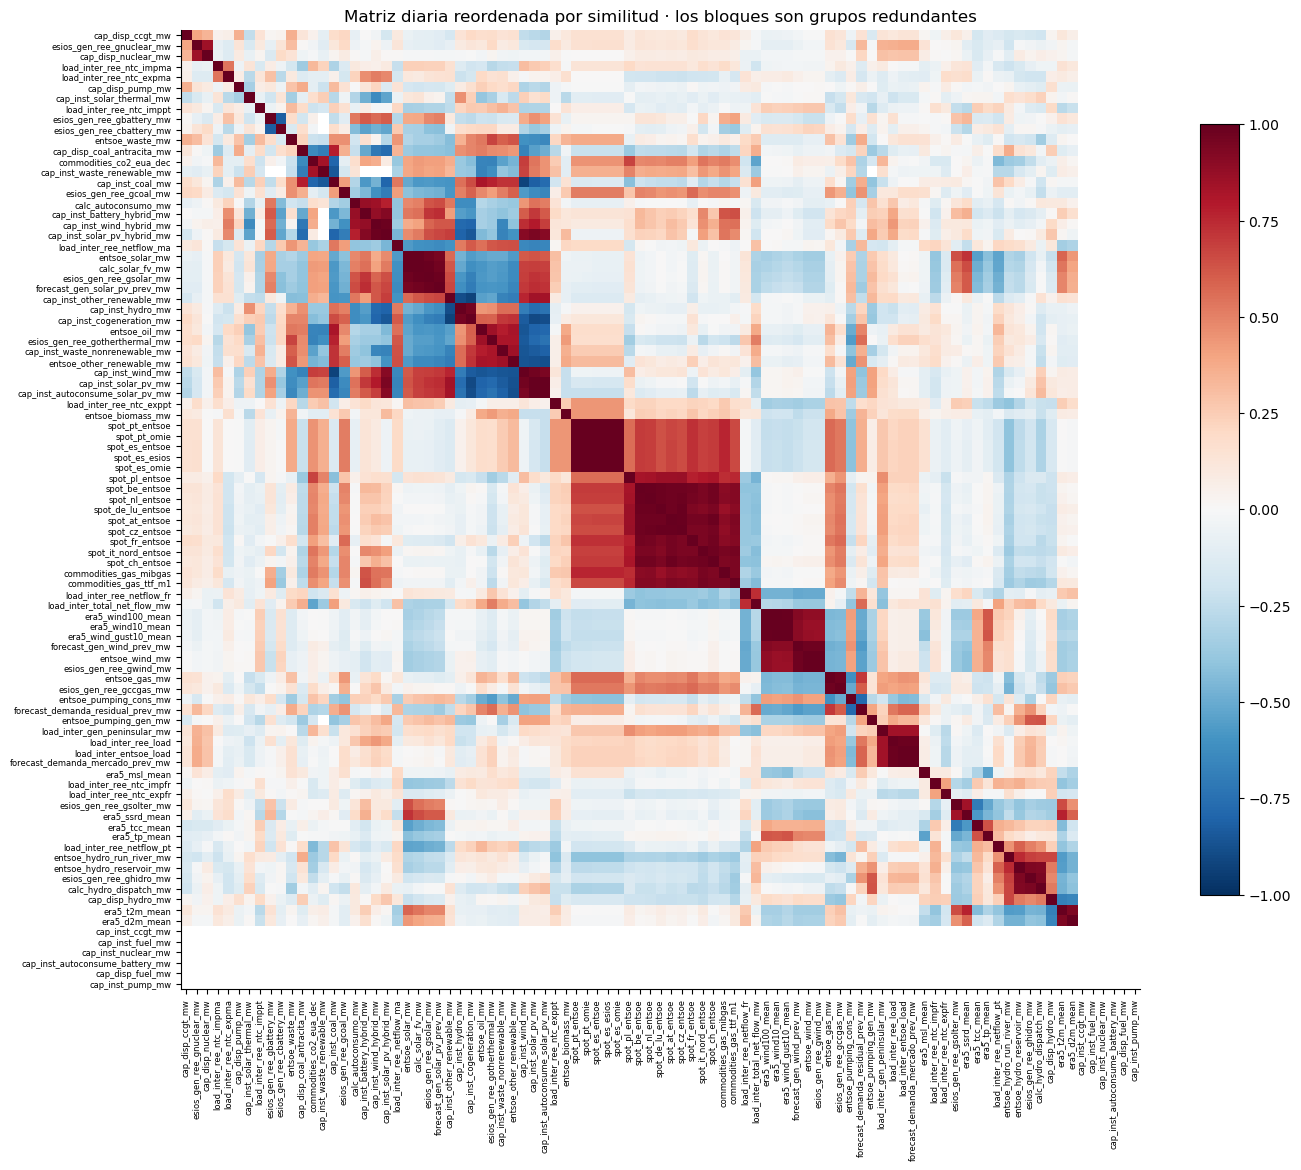

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# El agrupamiento se hace sobre el marco DIARIO: ahí todas las series comparten
# frecuencia y no hay pares indefinidos que haya que inventar.
DIA = df.groupby(df["ts_local"].dt.date)[num].mean()
DIA.index = pd.to_datetime(DIA.index)
C = DIA.corr()

print(f"Marco diario: {DIA.shape[0]:,} días x {DIA.shape[1]} columnas")
print(f"Pares indefinidos en la matriz diaria: {int(C.isna().sum().sum())//2:,} "
      f"(en la horaria eran {int(C_h.isna().sum().sum())//2:,})")

Cabs = C.abs()
A = Cabs.to_numpy(copy=True)          # copy=True: .values puede ser de sólo lectura
np.fill_diagonal(A, 1.0)
# Los NaN que queden se marcan como distancia máxima Y se listan, en vez de
# convertirlos en 0 en silencio como hacía la versión anterior.
n_nan = int(np.isnan(A).sum())
if n_nan:
    print(f"\nAviso: {n_nan//2} pares siguen indefinidos y se tratan como distancia máxima.")
A = np.nan_to_num(A, nan=0.0)
D = 1 - A
D = (D + D.T) / 2
np.fill_diagonal(D, 0.0)

Z = linkage(squareform(D, checks=False), method="average")
orden = dendrogram(Z, no_plot=True)["leaves"]
cols_ord = [C.columns[i] for i in orden]
C_ord = C.loc[cols_ord, cols_ord]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(C_ord.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C_ord)), C_ord.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(C_ord)), C_ord.columns, fontsize=6)
ax.set_title("Matriz diaria reordenada por similitud · los bloques son grupos redundantes")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

**El dendrograma, en horizontal.** Con 77 etiquetas, el formato vertical las deja a tamaño
5 y rotadas: ilegibles, y de ahí la sensación de que faltan columnas. En horizontal cada
etiqueta ocupa su propia línea y se leen todas — es el mismo árbol, girado.

Se colorea además por familia de origen, para ver de un vistazo si los grupos coinciden con las
tablas o los cruzan.

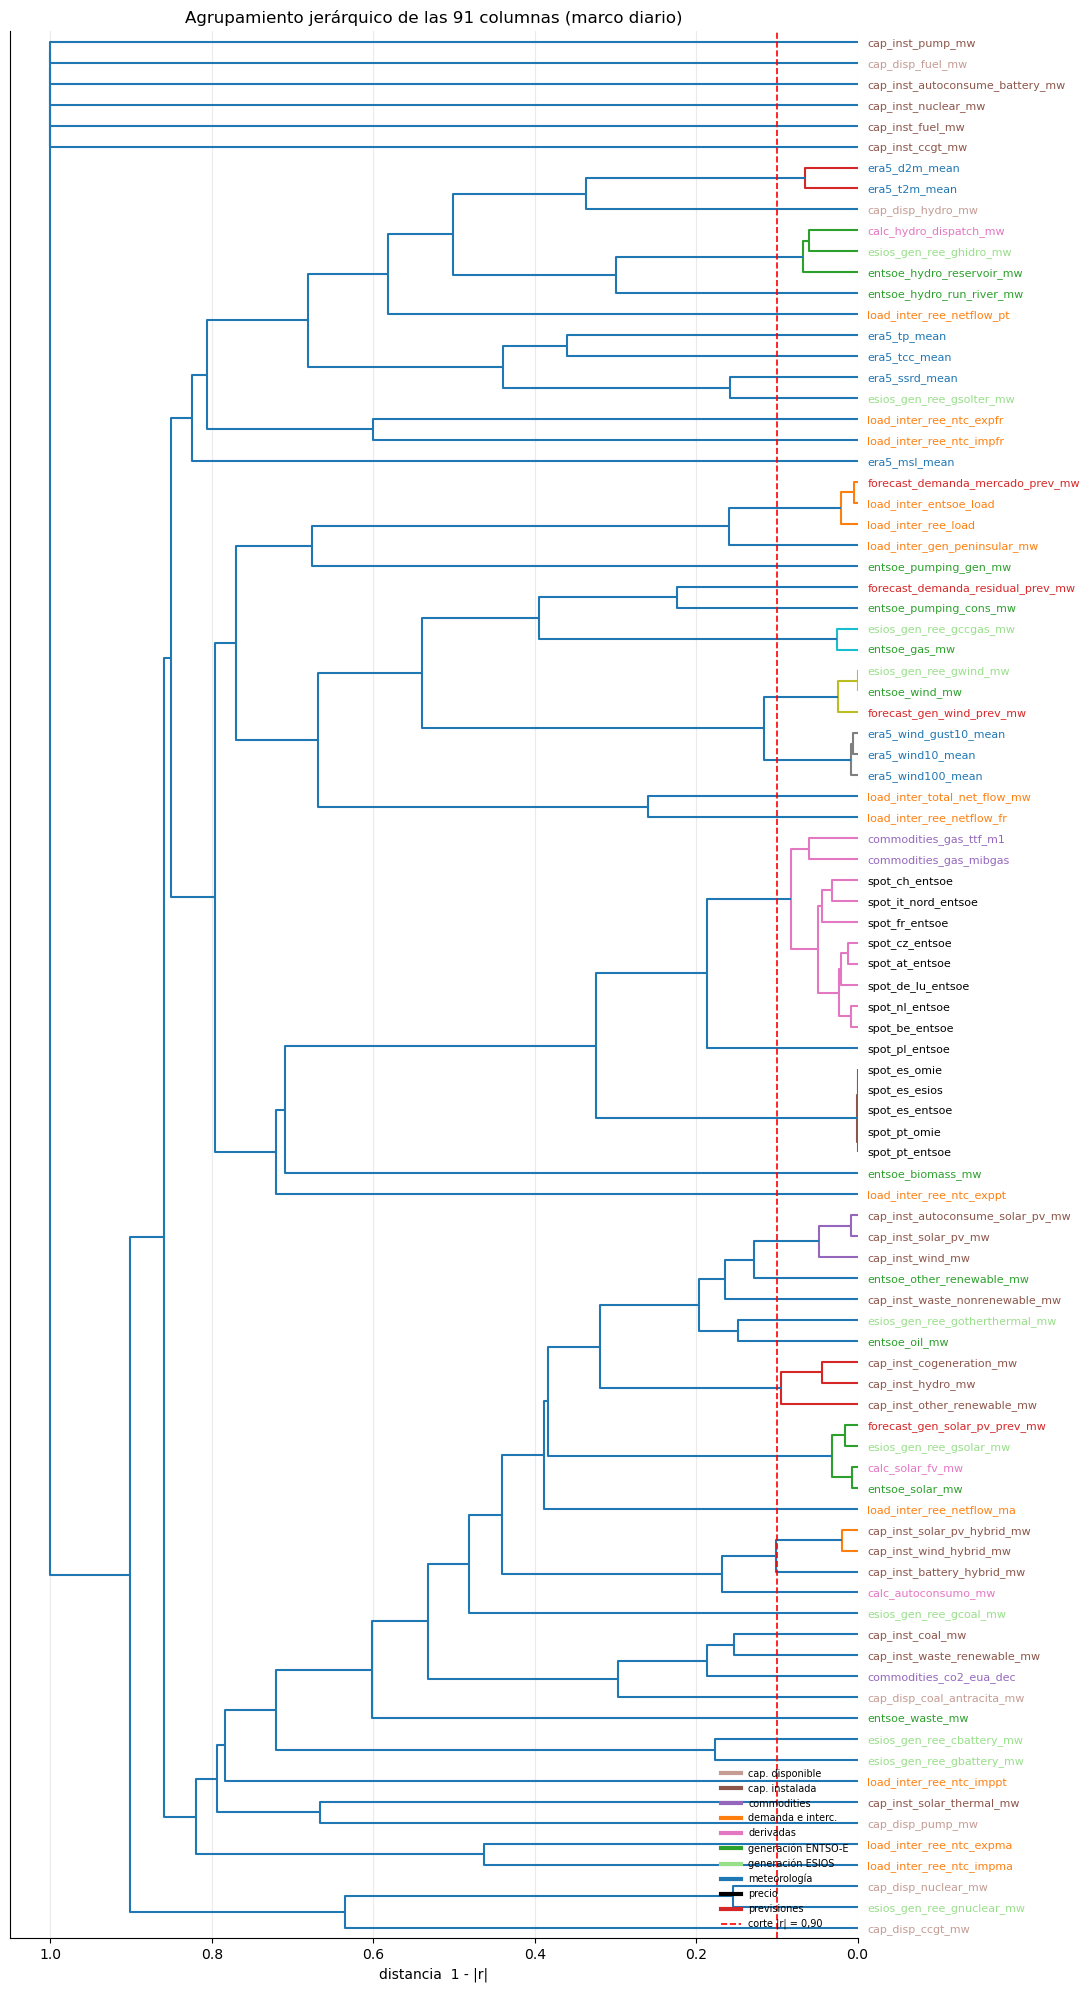

Se representan las 91 columnas. Comprobación por familia:


,en el árbol
cap. instalada,18
precio,14
demanda e interc.,13
generación ENTSO-E,11
generación ESIOS,10
meteorología,9
cap. disponible,6
previsiones,4
commodities,3
derivadas,3


In [23]:
COLOR_FAM = {
    "meteorología": "#1f77b4", "generación ENTSO-E": "#2ca02c", "generación ESIOS": "#98df8a",
    "demanda e interc.": "#ff7f0e", "previsiones": "#d62728", "commodities": "#9467bd",
    "cap. instalada": "#8c564b", "cap. disponible": "#c49c94", "derivadas": "#e377c2",
    "precio": "#000000", "trayport": "#7f7f7f", "otras": "#bcbd22",
}

altura = max(8, 0.22 * len(C.columns))
fig, ax = plt.subplots(figsize=(11, altura))
dd = dendrogram(Z, labels=list(C.columns), orientation="left",
                leaf_font_size=8, color_threshold=0.10, ax=ax)
ax.axvline(0.10, color="red", ls="--", lw=1.2,
           label="corte en 1-|r| = 0,10  (|r| >= 0,90)")
ax.set_xlabel("distancia  1 - |r|")
ax.set_title(f"Agrupamiento jerárquico de las {len(C.columns)} columnas (marco diario)")
ax.legend(frameon=False, loc="lower right"); ax.grid(False, axis="y")

# Colorear cada etiqueta según su familia de origen.
for etiqueta in ax.get_ymajorticklabels():
    etiqueta.set_color(COLOR_FAM.get(familia_de(etiqueta.get_text()), "black"))

from matplotlib.lines import Line2D
presentes = sorted({familia_de(c) for c in C.columns})
ax.legend(handles=[Line2D([0], [0], color=COLOR_FAM.get(f, "black"), lw=3, label=f)
                   for f in presentes] +
                  [Line2D([0], [0], color="red", ls="--", lw=1.2, label="corte |r| = 0,90")],
          frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

print(f"Se representan las {len(dd['ivl'])} columnas. Comprobación por familia:")
display(pd.Series([familia_de(c) for c in dd["ivl"]]).value_counts().rename("en el árbol").to_frame())

## A.3 · Sólo lo que supera un umbral

Tercer paso de reducción: **borrar del mapa todo lo que está por debajo de |r| = 0,7**. Lo que
queda es la estructura de redundancia sin el ruido de fondo de miles de correlaciones pequeñas
que no significan nada.

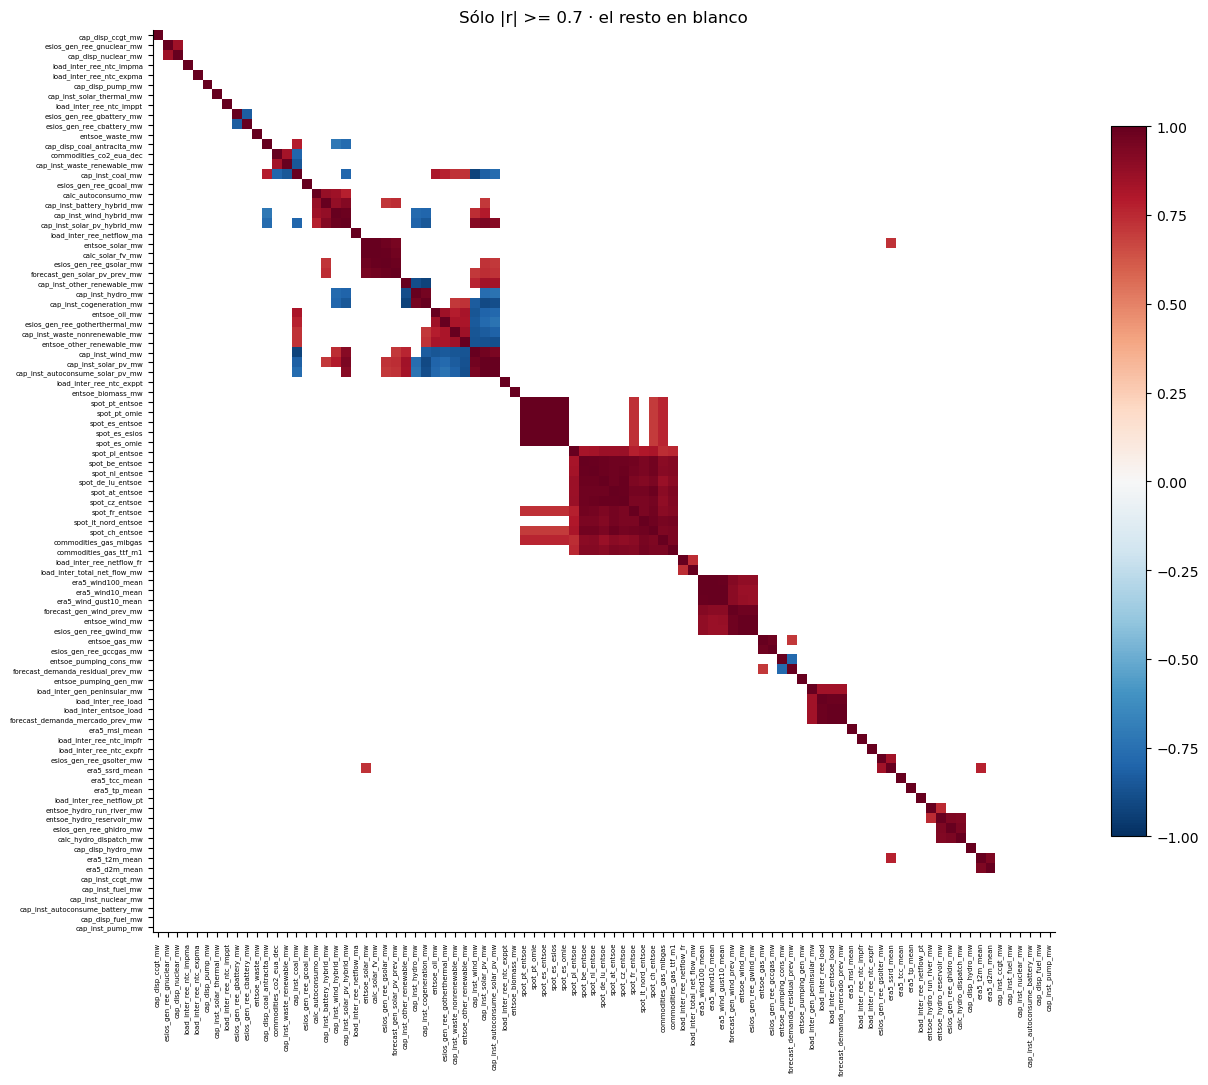

Quedan 189 pares de 4,095 (4.6%).
Todo lo blanco es ruido de fondo que en el primer mapa ocupaba el 95% de la imagen.


In [24]:
UMBRAL_VISUAL = 0.7
C_fuerte = C_ord.where(C_ord.abs() >= UMBRAL_VISUAL)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(C_fuerte.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(C_ord)), C_ord.columns, rotation=90, fontsize=5)
ax.set_yticks(range(len(C_ord)), C_ord.columns, fontsize=5)
ax.set_title(f"Sólo |r| >= {UMBRAL_VISUAL} · el resto en blanco")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

n_fuertes = int((C_fuerte.abs() >= UMBRAL_VISUAL).sum().sum() - len(C_ord))
print(f"Quedan {n_fuertes//2:,} pares de {len(C)*(len(C)-1)//2:,} "
      f"({n_fuertes/2/(len(C)*(len(C)-1)/2)*100:.1f}%).")
print("Todo lo blanco es ruido de fondo que en el primer mapa ocupaba el 95% de la imagen.")

## A.4 · Y ahora sí, como lista de pares



Los tres mapas anteriores enseñan **dónde** está la redundancia; para decidir hace falta saber
**entre qué columnas exactamente**, y eso sólo se lee en una lista ordenada. Es el último paso
de la reducción: de imagen a tabla.

**Nota sobre el método de correlación.** Se usa Pearson por comparabilidad con el resto del EDA,
pero conviene recordar lo del notebook 06: sólo ve relaciones lineales. Un par con Pearson bajo
puede seguir estando relacionado.

In [25]:
# Lista de pares por encima del umbral, sin duplicar (i<j) y sin la diagonal.
mask = np.triu(np.ones(C.shape, dtype=bool), k=1)
pares = (C.where(mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"}))
pares["abs_r"] = pares["r"].abs()

UMBRAL = 0.95
redundantes = pares[pares["abs_r"] >= UMBRAL].sort_values("abs_r", ascending=False)
print(f"Pares con |r| >= {UMBRAL}: {len(redundantes)}")
display(redundantes[["a", "b", "r"]].head(25).round(4).reset_index(drop=True))

Pares con |r| >= 0.95: 52


,a,b,r
0,spot_es_esios,spot_es_omie,1.0000
1,spot_pt_entsoe,spot_pt_omie,1.0000
2,spot_es_esios,spot_es_entsoe,1.0000
3,spot_es_entsoe,spot_es_omie,1.0000
4,entsoe_wind_mw,esios_gen_ree_gwind_mw,0.9999
5,spot_es_entsoe,spot_pt_entsoe,0.9988
6,spot_es_omie,spot_pt_omie,0.9988
7,spot_es_esios,spot_pt_omie,0.9988
8,spot_es_esios,spot_pt_entsoe,0.9988
9,spot_es_entsoe,spot_pt_omie,0.9988


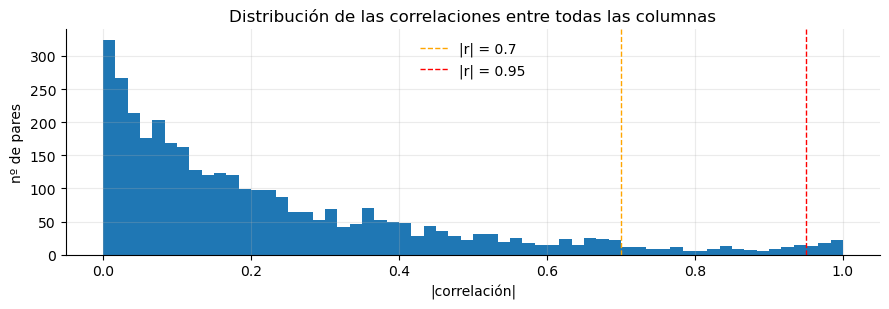

  |r| >= 0.7:   192 pares (5.4%)
  |r| >= 0.9:    87 pares (2.4%)
  |r| >= 0.95:    52 pares (1.5%)
  |r| >= 0.99:    18 pares (0.5%)


In [26]:
# Distribución de las correlaciones: cuánta redundancia hay en total.
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(pares["abs_r"].dropna(), bins=60)
for u, col in [(0.7, "orange"), (0.95, "red")]:
    ax.axvline(u, color=col, ls="--", lw=1, label=f"|r| = {u}")
ax.set_xlabel("|correlación|"); ax.set_ylabel("nº de pares")
ax.set_title("Distribución de las correlaciones entre todas las columnas")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

for u in (0.7, 0.9, 0.95, 0.99):
    n = (pares["abs_r"] >= u).sum()
    print(f"  |r| >= {u}: {n:>5,} pares ({n/len(pares)*100:.1f}%)")

---
## B · Mapa por familias

La matriz completa sí es legible **si se agrega por familia de origen**: en vez de 83×83, una
matriz de 9×9 con la correlación media absoluta entre cada par de grupos. Dice de un vistazo qué
bloques del bronce se solapan.

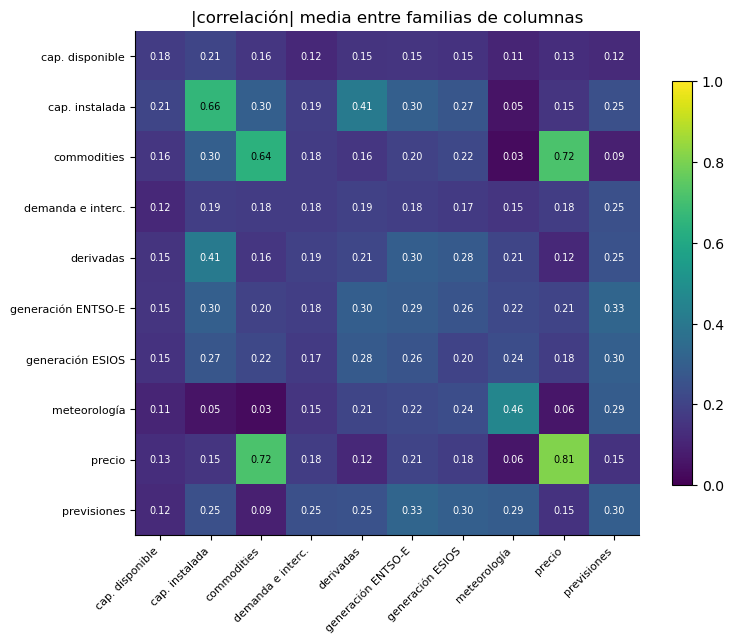

,cap. disponible,cap. instalada,commodities,demanda e interc.,derivadas,generación ENTSO-E,generación ESIOS,meteorología,precio,previsiones
cap. disponible,0.180,0.208,0.157,0.115,0.150,0.154,0.148,0.105,0.133,0.119
cap. instalada,0.208,0.660,0.302,0.186,0.410,0.305,0.266,0.051,0.154,0.246
commodities,0.157,0.302,0.643,0.179,0.157,0.198,0.217,0.030,0.717,0.087
demanda e interc.,0.115,0.186,0.179,0.179,0.193,0.185,0.170,0.153,0.182,0.246
derivadas,0.150,0.410,0.157,0.193,0.214,0.299,0.282,0.208,0.117,0.253
generación ENTSO-E,0.154,0.305,0.198,0.185,0.299,0.288,0.260,0.219,0.206,0.327
generación ESIOS,0.148,0.266,0.217,0.170,0.282,0.260,0.200,0.237,0.181,0.304
meteorología,0.105,0.051,0.030,0.153,0.208,0.219,0.237,0.460,0.062,0.291
precio,0.133,0.154,0.717,0.182,0.117,0.206,0.181,0.062,0.809,0.146
previsiones,0.119,0.246,0.087,0.246,0.253,0.327,0.304,0.291,0.146,0.301


In [27]:
fam = pd.Series({c: familia_de(c) for c in num})
grupos = sorted(fam.unique())

M = pd.DataFrame(index=grupos, columns=grupos, dtype=float)
for g1 in grupos:
    for g2 in grupos:
        c1, c2 = fam[fam == g1].index, fam[fam == g2].index
        sub = C.loc[c1, c2].abs()
        if g1 == g2:
            sub = sub.where(np.triu(np.ones(sub.shape, dtype=bool), k=1))
        M.loc[g1, g2] = sub.stack().mean()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(M.values.astype(float), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(grupos)), grupos, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(grupos)), grupos, fontsize=8)
for i in range(len(grupos)):
    for j in range(len(grupos)):
        v = M.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v < 0.6 else "black")
ax.set_title("|correlación| media entre familias de columnas"); ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
display(M.round(3))

---
## C · ¿La correlación sobrevive dentro de cada año?

**El problema.** El bronce cubre seis años y medio con tendencias muy fuertes: la FV instalada
pasa de 8.659 a 54.668 MW, el carbón se cierra, el autoconsumo aparece en 2025. Dos series que
crecen o caen a la vez correlacionan **aunque no tengan relación causal alguna**.

**La comprobación.** Calcular la misma correlación *dentro* de cada año y compararla con la
global. Si la global es alta y las anuales son bajas, la relación era tendencia compartida. Si
las anuales se mantienen, la relación es real.

**Consecuencia directa para el modelado.** Una feature elegida por una correlación que sólo
existe entre años no generaliza: en producción el modelo ve un año concreto, no el histórico.

In [28]:
# Se examinan los pares fuertes -- que son los que se usarían para descartar columnas.
CANDIDATOS = pares[pares["abs_r"] >= 0.80].sort_values("abs_r", ascending=False).head(30)

filas = []
for _, row in CANDIDATOS.iterrows():
    a, b = row["a"], row["b"]
    por_anio = df.groupby("anio").apply(
        lambda g: g[a].corr(g[b]) if g[[a, b]].dropna().shape[0] > 200 else np.nan,
        include_groups=False).dropna()
    if len(por_anio) < 3:
        continue
    filas.append({"a": a, "b": b, "r_global": row["r"],
                  "r_anual_media": por_anio.mean(),
                  "r_anual_min": por_anio.min(),
                  "caída": abs(row["r"]) - por_anio.abs().mean()})

E = pd.DataFrame(filas).set_index(["a", "b"])
print("Ordenado por CAÍDA: arriba, los pares cuya correlación se desmorona dentro del año.")
display(E.sort_values("caída", ascending=False).head(15).round(4))
print("\nCaída grande = la correlación global venía de la tendencia común, no de la relación.")
print("Caída ~0 = relación estable, real dentro de cada año.")

Ordenado por CAÍDA: arriba, los pares cuya correlación se desmorona dentro del año.


r_global  r_anual_media  r_anual_min   caída
a                       b                                                                             
era5_wind100_mean       era5_wind_gust10_mean               0.9901         0.9081       0.8786  0.0820
spot_nl_entsoe          spot_cz_entsoe                      0.9769         0.9015       0.8679  0.0755
spot_ch_entsoe          spot_at_entsoe                      0.9779         0.9050       0.8067  0.0729
cap_inst_wind_hybrid_mw cap_inst_solar_pv_hybrid_mw         0.9811         0.9230       0.8499  0.0581
spot_de_lu_entsoe       spot_cz_entsoe                      0.9853         0.9285       0.8609  0.0568
                        spot_be_entsoe                      0.9772         0.9277       0.8961  0.0494
                        spot_nl_entsoe                      0.9815         0.9393       0.8611  0.0422
spot_be_entsoe          spot_nl_entsoe                      0.9915         0.9556       0.9199  0.0359
cap_inst_solar_pv_mw    cap_inst_autoconsume_solar_pv_mw    0.9923         0.9573       0.7677  0.0350
spot_at_entsoe          spot_cz_entsoe                      0.9886         0.9541       0.9411  0.0345
era5_wind10_mean        era5_wind_gust10_mean               0.9943         0.9706       0.9609  0.0237
                        era5_wind100_mean                   0.9933         0.9715       0.9608  0.0218
entsoe_wind_mw          forecast_gen_wind_prev_mw           0.9761         0.9563       0.9047  0.0198
spot_es_omie            spot_pt_omie                        0.9988         0.9928       0.9798  0.0060
spot_es_esios           spot_pt_omie                        0.9988         0.9928       0.9798  0.0060


Caída grande = la correlación global venía de la tendencia común, no de la relación.
Caída ~0 = relación estable, real dentro de cada año.


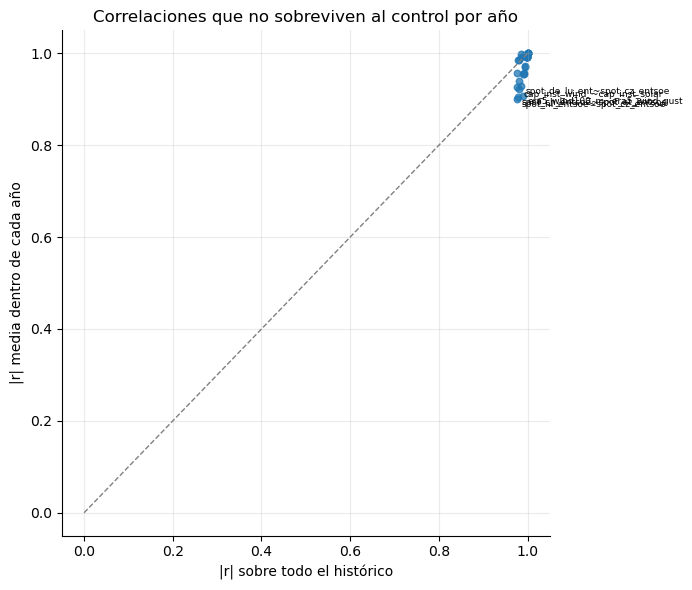

Los puntos muy por DEBAJO de la diagonal son correlaciones espurias por tendencia.


In [29]:
if len(E):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(E["r_global"].abs(), E["r_anual_media"].abs(), s=22, alpha=0.75)
    ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    peor = E.reindex(E["caída"].sort_values(ascending=False).index).head(5)
    for (a, b), row in peor.iterrows():
        ax.annotate(f"{a[:14]}~{b[:14]}", (abs(row["r_global"]), abs(row["r_anual_media"])),
                    fontsize=6.5, xytext=(3, -6), textcoords="offset points")
    ax.set_xlabel("|r| sobre todo el histórico"); ax.set_ylabel("|r| media dentro de cada año")
    ax.set_title("Correlaciones que no sobreviven al control por año")
    plt.tight_layout(); plt.show()
    print("Los puntos muy por DEBAJO de la diagonal son correlaciones espurias por tendencia.")

---
## D · Matriz restringida a las candidatas

**Ahora sí, la matriz que se mira de verdad.** Un subconjunto acotado y con la etiqueta de fuga
pegada a cada columna, porque mezclar variables con y sin fuga en la misma matriz lleva a
conclusiones inservibles: da igual que dos columnas sean redundantes si ninguna de las dos se
puede usar.

La lista sale de la tabla de veredictos del notebook 03. Se declara explícitamente en vez de
tomarse por prefijo, para que sea revisable — y para que cualquiera vea qué entró y qué no.

In [30]:
CANDIDATAS = {
    # --- SIN FUGA: previsiones, disponibles a las 12:00 de D
    "demanda prevista":    (pick(df, "forecast_demanda_mercado_prev_mw", "fc_ree_demanda_prev"), "SIN FUGA"),
    "eólica prevista":     (pick(df, "forecast_gen_wind_prev_mw", "fc_ree_gwind_prev"), "SIN FUGA"),
    "solar prevista":      (pick(df, "forecast_gen_solar_pv_prev_mw", "fc_ree_gsolar_prev"), "SIN FUGA"),
    "renovable prevista":  (pick(df, "forecast_gen_renovables_prev_mw", "fc_ree_grenov_prev"), "SIN FUGA"),
    # --- CON DESFASE: commodities, último dato D-2
    "gas":                 (pick(df, "tp_ttf_cierre", "commodities_gas_ttf_m1"), "DESFASE D-2"),
    "CO2":                 (pick(df, "tp_eua_cierre", "commodities_co2_eua_dec"), "DESFASE D-2"),
    # --- CON FUGA: reales, sólo con lag
    "demanda real":        (pick(df, "load_inter_entsoe_load"), "CON FUGA"),
    "eólica real":         (pick(df, "entsoe_wind_mw", "gen_ent_gwind"), "CON FUGA"),
    "solar FV real":       (pick(df, "calc_solar_fv_mw", "gen_c_gsolar"), "CON FUGA"),
    "hidráulica desp.":    (pick(df, "calc_hydro_dispatch_mw", "gen_c_ghydrodispatch"), "CON FUGA"),
    "nuclear":             (pick(df, "entsoe_nuclear_mw", "esios_gen_ree_gnuclear_mw"), "CON FUGA"),
    "ciclo combinado":     (pick(df, "esios_gen_ree_gccgas_mw", "gen_ree_gccgt"), "CON FUGA"),
    "saldo Francia":       (pick(df, "load_inter_ree_netflow_fr"), "CON FUGA"),
    "saldo Portugal":      (pick(df, "load_inter_ree_netflow_pt"), "CON FUGA"),
    # --- METEO: reanálisis, con fuga salvo con lag
    "temperatura":         (pick(df, "era5_t2m_mean"), "CON FUGA (ERA5)"),
    "viento 100m":         (pick(df, "era5_wind100_mean"), "CON FUGA (ERA5)"),
    "radiación":           (pick(df, "era5_ssrd_mean"), "CON FUGA (ERA5)"),
    # --- TARGET, si ya está en el bronce
    "PRECIO ES":           (pick(df, "spot_es_omie", "es_omie"), "TARGET"),
}
CANDIDATAS = {k: v for k, v in CANDIDATAS.items() if v[0]}
print(f"{len(CANDIDATAS)} candidatas resueltas:")
for k, (c, f) in CANDIDATAS.items():
    print(f"  {k:20s} {f:16s} {c}")
faltan = [k for k in ("PRECIO ES",) if k not in CANDIDATAS]
if faltan:
    print(f"\nNo disponibles todavía: {faltan} -- añadir spot_price al bronce.")

17 candidatas resueltas:
  demanda prevista     SIN FUGA         forecast_demanda_mercado_prev_mw
  eólica prevista      SIN FUGA         forecast_gen_wind_prev_mw
  solar prevista       SIN FUGA         forecast_gen_solar_pv_prev_mw
  gas                  DESFASE D-2      commodities_gas_ttf_m1
  CO2                  DESFASE D-2      commodities_co2_eua_dec
  demanda real         CON FUGA         load_inter_entsoe_load
  eólica real          CON FUGA         entsoe_wind_mw
  solar FV real        CON FUGA         calc_solar_fv_mw
  hidráulica desp.     CON FUGA         calc_hydro_dispatch_mw
  nuclear              CON FUGA         esios_gen_ree_gnuclear_mw
  ciclo combinado      CON FUGA         esios_gen_ree_gccgas_mw
  saldo Francia        CON FUGA         load_inter_ree_netflow_fr
  saldo Portugal       CON FUGA         load_inter_ree_netflow_pt
  temperatura          CON FUGA (ERA5)  era5_t2m_mean
  viento 100m          CON FUGA (ERA5)  era5_wind100_mean
  radiación            CON 

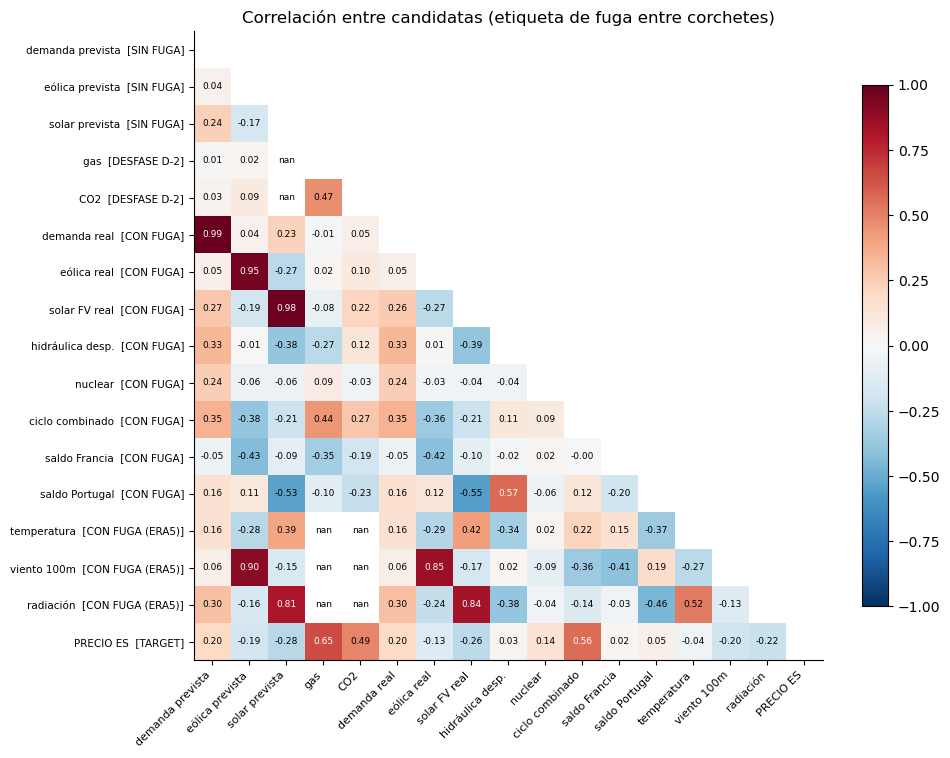

In [31]:
cols = {k: v[0] for k, v in CANDIDATAS.items()}
sub = df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
Cs = sub.corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
mask = np.triu(np.ones_like(Cs, dtype=bool))
im = ax.imshow(np.where(mask, np.nan, Cs.values), cmap="RdBu_r", vmin=-1, vmax=1)
etq = [f"{k}  [{CANDIDATAS[k][1]}]" for k in Cs.columns]
ax.set_xticks(range(len(Cs)), Cs.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(Cs)), etq, fontsize=7.5)
for i in range(len(Cs)):
    for j in range(i):
        ax.text(j, i, f"{Cs.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(Cs.iloc[i, j]) > 0.55 else "black")
ax.set_title("Correlación entre candidatas (etiqueta de fuga entre corchetes)")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

In [32]:
# Sólo entre las utilizables: es la matriz que de verdad decide el conjunto de features.
usables = [k for k, (c, f) in CANDIDATAS.items() if f in ("SIN FUGA", "DESFASE D-2")]
if len(usables) >= 3:
    Cu = sub[usables].corr()
    display(Cu.round(3))
    m = np.triu(np.ones(Cu.shape, dtype=bool), k=1)
    p = Cu.where(m).stack().rename("r").reset_index()
    p["abs"] = p["r"].abs()
    print("\nPares redundantes entre las utilizables (|r| >= 0,9):")
    display(p[p["abs"] >= 0.9].sort_values("abs", ascending=False).round(4))
    print("Si 'renovable prevista' correlaciona ~1 con la suma de eólica y solar previstas, "
          "es que ES esa suma: no aporta una tercera feature, aporta la misma información.")

,demanda prevista,eólica prevista,solar prevista,gas,CO2
demanda prevista,1.000,0.041,0.240,0.008,0.034
eólica prevista,0.041,1.000,-0.171,0.017,0.093
solar prevista,0.240,-0.171,1.000,NaN,NaN
gas,0.008,0.017,NaN,1.000,0.469
CO2,0.034,0.093,NaN,0.469,1.000



Pares redundantes entre las utilizables (|r| >= 0,9):


,level_0,level_1,r,abs


Si 'renovable prevista' correlaciona ~1 con la suma de eólica y solar previstas, es que ES esa suma: no aporta una tercera feature, aporta la misma información.


---
## E · Grupos de redundancia

**Para qué sirve.** En vez de mirar pares uno a uno, agrupar las columnas que se comportan como
la misma variable. De cada grupo basta con quedarse con **una**, elegida por criterio —menos
nulos, fuente preferida por una decisión ya tomada, o la que tenga mejor cobertura temporal.

El agrupamiento se hace con enlace jerárquico sobre la distancia `1 − |r|`, cortando a un umbral
declarado. No es magia: es una forma de leer la matriz completa sin mirar 3.403 pares.

In [33]:
# Se reutiliza el linkage Z ya calculado en A.2: es el mismo agrupamiento que
# reordenó el mapa, ahora cortado a una altura concreta para obtener grupos.
UMBRAL_GRUPO = 0.10        # 1 - |r| = 0,10  ->  |r| >= 0,90 dentro del grupo
etiquetas = fcluster(Z, t=UMBRAL_GRUPO, criterion="distance")

G = pd.DataFrame({"columna": C.columns, "grupo": etiquetas})
tam = G["grupo"].value_counts()
multi = tam[tam > 1].index

print(f"{len(multi)} grupos con más de una columna (|r| >= {1-UMBRAL_GRUPO:.2f} dentro del grupo):\n")
for g in multi:
    miembros = G.loc[G["grupo"] == g, "columna"].tolist()
    nulos = df[miembros].isna().mean().mul(100).round(1)
    print(f"  Grupo {g} ({len(miembros)} columnas):")
    for m in miembros:
        print(f"     {m:42s} {nulos[m]:>5.1f}% nulos")
    print(f"     -> sugerencia: quedarse con '{nulos.idxmin()}' (menos nulos)\n")

12 grupos con más de una columna (|r| >= 0.90 dentro del grupo):

  Grupo 29 (10 columnas):
     spot_fr_entsoe                               0.0% nulos
     spot_de_lu_entsoe                            0.0% nulos
     spot_it_nord_entsoe                          0.1% nulos
     spot_ch_entsoe                               0.0% nulos
     spot_be_entsoe                               0.0% nulos
     spot_nl_entsoe                               0.0% nulos
     spot_at_entsoe                               0.0% nulos
     spot_cz_entsoe                               0.0% nulos
     commodities_gas_mibgas                      95.8% nulos
     commodities_gas_ttf_m1                      97.1% nulos
     -> sugerencia: quedarse con 'spot_fr_entsoe' (menos nulos)

  Grupo 28 (5 columnas):
     spot_es_esios                                0.0% nulos
     spot_es_entsoe                               0.0% nulos
     spot_es_omie                                 0.1% nulos
     spot_pt_entsoe      

**Cómo usar esto, y cómo no.**

Que dos columnas caigan en el mismo grupo **no significa que sobre una automáticamente**. Hay
casos en que la redundancia estadística convive con una diferencia conceptual que importa: la
eólica de ESIOS y la de ENTSO-E correlacionan 0,9996 y son intercambiables, pero el gas de
ENTSO-E y el CCGT de ESIOS también correlacionan alto y **no lo son** (D-02: uno mezcla
cogeneración y el otro no).

La regla es: el agrupamiento **propone**, la decisión documentada **dispone**. Cuando exista una
decisión del equipo sobre qué fuente usar, esa manda sobre el resultado del clúster.

---
## F · ¿Cuánta información distinta hay realmente?

**La pregunta que ni la matriz ni el dendrograma responden.** Los dos dicen qué pares o grupos
se solapan, pero no **cuántas dimensiones independientes** hay en el conjunto. Setenta y siete
columnas no son setenta y siete piezas de información: si la mitad son variantes de la misma
cosa, la dimensionalidad efectiva es mucho menor.

**Cómo se mide.** Con el análisis de componentes principales sobre las variables estandarizadas.
El número de componentes necesarias para explicar el 90 % de la varianza es una medida directa
de cuánta información distinta hay.

**Para qué sirve aquí, y para qué no.** Sirve como **diagnóstico**: si 77 columnas se resumen en
8 componentes, sobra muchísima redundancia y el dendrograma se queda corto. No propongo usar las
componentes como features — perderían la etiqueta de fuga, que es lo último que conviene perder
en este proyecto: una componente que mezcla previsiones con generación real es inutilizable
aunque explique mucha varianza.

Días completos para el PCA: 393 de 2,430
  70% de la varianza -> 5 componentes de 91
  80% de la varianza -> 9 componentes de 91
  90% de la varianza -> 16 componentes de 91
  95% de la varianza -> 25 componentes de 91


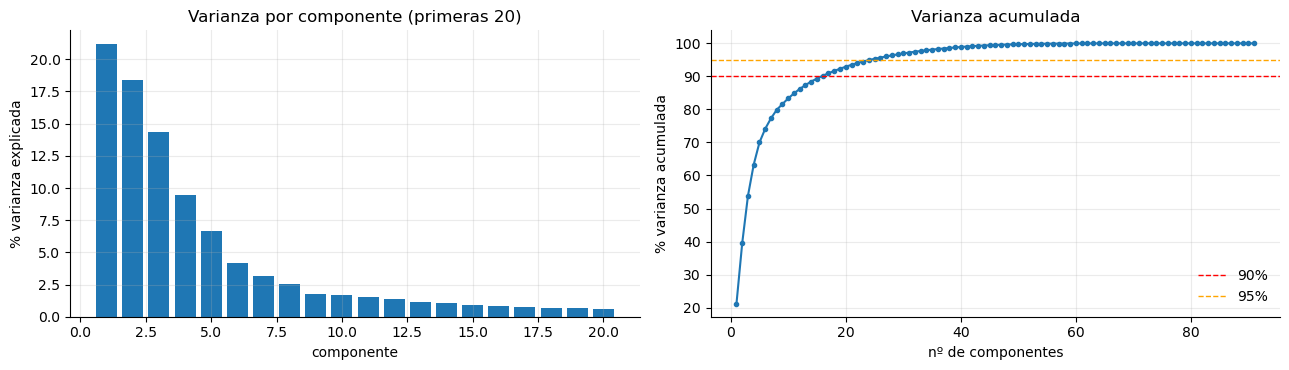

In [34]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = DIA[num].dropna()
print(f"Días completos para el PCA: {len(X):,} de {len(DIA):,}")
if len(X) < 100:
    # Si exigir todas las columnas deja pocos días, se usan las de cobertura alta.
    buenas = [c for c in num if DIA[c].notna().mean() > 0.95]
    X = DIA[buenas].dropna()
    print(f"Pocos días completos: se usan las {len(buenas)} columnas con >95% de cobertura "
          f"-> {len(X):,} días")

Xs = StandardScaler().fit_transform(X)
pca = PCA().fit(Xs)
var = pd.Series(pca.explained_variance_ratio_ * 100,
                index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))])
acum = var.cumsum()

for u in (70, 80, 90, 95):
    k = int((acum < u).sum() + 1)
    print(f"  {u}% de la varianza -> {k} componentes de {X.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(range(1, min(21, len(var) + 1)), var.values[:20])
axes[0].set_xlabel("componente"); axes[0].set_ylabel("% varianza explicada")
axes[0].set_title("Varianza por componente (primeras 20)")
axes[1].plot(range(1, len(acum) + 1), acum.values, marker="o", ms=3)
for u, col in [(90, "red"), (95, "orange")]:
    axes[1].axhline(u, color=col, ls="--", lw=1, label=f"{u}%")
axes[1].set_xlabel("nº de componentes"); axes[1].set_ylabel("% varianza acumulada")
axes[1].set_title("Varianza acumulada"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

In [35]:
# Qué mide cada una de las primeras componentes: las cargas más altas le dan nombre.
cargas = pd.DataFrame(pca.components_[:4].T, index=X.columns,
                      columns=[f"PC{i+1}" for i in range(4)])
for pc in cargas.columns:
    top = cargas[pc].abs().nlargest(6)
    print(f"\n{pc} ({var[pc]:.1f}% de la varianza) -- variables con más peso:")
    for v in top.index:
        print(f"    {cargas.loc[v, pc]:+.3f}  {v[:46]}  [{familia_de(v)}]")

print("\nSi una componente carga a la vez sobre columnas SIN FUGA y CON FUGA, ilustra por qué")
print("no sirve como feature: mezcla información disponible con información que no lo estará.")


PC1 (21.2% de la varianza) -- variables con más peso:
    +0.201  esios_gen_ree_gsolar_mw  [generación ESIOS]
    +0.197  forecast_gen_solar_pv_prev_mw  [previsiones]
    +0.196  calc_solar_fv_mw  [derivadas]
    +0.193  entsoe_solar_mw  [generación ENTSO-E]
    +0.177  era5_t2m_mean  [meteorología]
    +0.164  cap_inst_other_renewable_mw  [cap. instalada]

PC2 (18.4% de la varianza) -- variables con más peso:
    +0.238  spot_es_entsoe  [precio]
    +0.238  spot_es_esios  [precio]
    +0.238  spot_es_omie  [precio]
    +0.238  spot_pt_entsoe  [precio]
    +0.238  spot_pt_omie  [precio]
    +0.207  forecast_demanda_residual_prev_mw  [previsiones]

PC3 (14.3% de la varianza) -- variables con más peso:
    +0.201  spot_at_entsoe  [precio]
    +0.198  spot_ch_entsoe  [precio]
    +0.183  spot_cz_entsoe  [precio]
    +0.182  cap_inst_solar_pv_mw  [cap. instalada]
    +0.179  cap_inst_wind_hybrid_mw  [cap. instalada]
    +0.176  spot_it_nord_entsoe  [precio]

PC4 (9.4% de la varianza) -- v

In [36]:
print("RESUMEN")
print("=" * 62)
for l in [
    "",
    "Matriz COMPLETA -> se lee como lista de pares, no como imagen. Sirve para:",
    "   · detectar columnas redundantes que no hace falta traer al modelado",
    "   · agrupar familias que miden lo mismo (bloque E)",
    "",
    "Matriz RESTRINGIDA -> es la que decide el conjunto de features. Sirve para:",
    "   · ver si dos candidatas aportan la misma información",
    "   · y siempre con la etiqueta de fuga: una redundancia entre dos columnas",
    "     inutilizables no es una decisión, es ruido",
    "",
    "Y ninguna de las dos vale sin el control por año del bloque C: sobre seis años",
    "con tendencias fuertes, una correlación alta puede ser sólo tendencia compartida.",
    "",
    "F · El PCA cierra el diagnóstico: dice cuántas dimensiones independientes hay",
    "   de verdad. Es diagnóstico, no propuesta de features: una componente que mezcla",
    "   previsiones con generación real pierde la etiqueta de fuga y es inutilizable.",
    "",
    "PENDIENTE: rehacer los bloques D, E y F con spot_price en el bronce. Hasta entonces",
    "la matriz de candidatas no incluye el target, que es la columna que más importa.",
]:
    print(l)

RESUMEN

Matriz COMPLETA -> se lee como lista de pares, no como imagen. Sirve para:
   · detectar columnas redundantes que no hace falta traer al modelado
   · agrupar familias que miden lo mismo (bloque E)

Matriz RESTRINGIDA -> es la que decide el conjunto de features. Sirve para:
   · ver si dos candidatas aportan la misma información
   · y siempre con la etiqueta de fuga: una redundancia entre dos columnas
     inutilizables no es una decisión, es ruido

Y ninguna de las dos vale sin el control por año del bloque C: sobre seis años
con tendencias fuertes, una correlación alta puede ser sólo tendencia compartida.

F · El PCA cierra el diagnóstico: dice cuántas dimensiones independientes hay
   de verdad. Es diagnóstico, no propuesta de features: una componente que mezcla
   previsiones con generación real pierde la etiqueta de fuga y es inutilizable.

PENDIENTE: rehacer los bloques D, E y F con spot_price en el bronce. Hasta entonces
la matriz de candidatas no incluye el target, qu